In [1]:
from pyspark.sql import SparkSession
from pathlib import Path
import matplotlib.pyplot as plt

spark = SparkSession.builder \
    .appName("csgo-data-extract") \
    .getOrCreate()
print("Spark:", spark.version)


Spark: 3.5.0


## Extração e organização dos dados provindos do dataset original

In [2]:
# leitura
spark.read.option("recursiveFileLookup", "true") \
    .parquet("/home/jovyan/work/data/matchdata_split") \
    .createOrReplaceTempView("raw")

# transformação + escrita
spark.sql("""
SELECT
    -- ===== colunas transformadas =====
    CAST(tick / 128 AS INT) AS tick,
    ROUND(kills_from_avg, 2) AS kills_from_avg,
    ROUND(deaths_from_avg, 2) AS deaths_from_avg,
    ROUND(distance_closest_enemy / 100, 1) AS distance_closest_enemy,

    CAST(isBlinded AS INT) AS isBlinded,
    CAST(isAirborne AS INT) AS isAirborne,
    CAST(isDucking AS INT) AS isDucking,
    CAST(isStanding AS INT) AS isStanding,
    CAST(isScoped AS INT) AS isScoped,
    CAST(isWalking AS INT) AS isWalking,
    CAST(hasHelmet AS INT) AS hasHelmet,

    -- ===== colunas originais =====
    hp,
    armor,
    equipmentValue,
    cash,
    total_hp_enemy,
    total_hp_team,
    num_enemy_alive,
    num_team_alive,
    enemy_in_range_200,
    enemy_in_range_500,
    enemy_in_range_1000,
    enemy_in_range_2000,

    enemy_hp_in_range_500,
    enemy_hp_in_range_1000,
    enemy_hp_in_range_2000,

    enemy_equipment_in_range_500,
    enemy_equipment_in_range_1000,
    enemy_equipment_in_range_2000,

    team_in_range_200,
    team_in_range_500,
    team_in_range_1000,

    equipment_value_team,
    equipment_value_enemy,

    hp_closest_enemy,

    activeWeapon,
    weapon_closest_enemy,

    isAlive,
    isDead,

    roundNum,

    -- ===== novas colunas =====

    CAST(regexp_extract(input_file_name(), 'Player-([0-9]+)', 1) AS INT) AS player,

    CASE 
        WHEN regexp_extract(input_file_name(), 'matchdata_split/([^/]+)', 1) LIKE '%-%'
        THEN regexp_extract(regexp_extract(input_file_name(), 'matchdata_split/([^/]+)', 1), '(.+)-[^-]+$', 1)
        ELSE regexp_extract(input_file_name(), 'matchdata_split/([^/]+)', 1)
    END AS match,

    CASE 
        WHEN regexp_extract(input_file_name(), 'matchdata_split/([^/]+)', 1) LIKE '%-%'
        THEN regexp_extract(regexp_extract(input_file_name(), 'matchdata_split/([^/]+)', 1), '-([^-]+)$', 1)
        ELSE 'unknown'
    END AS map

FROM raw
""") \
.coalesce(16) \
.write \
.mode("overwrite") \
.parquet("/home/jovyan/work/data/csgo_full_dataset")

## Visão geral dos dados e comparando com o original pois um dataset ir de 6.6gb (já em parquet) ir pra 143mb é inesperado

### TEMPVIEW DO DATASET USADO NA EDA E ETC, coloquei separado pra ficar mais fácil de rodar alguma celula em especifico caso tenha que resetar o kernel

In [2]:
# cria tempview
spark.read.parquet("/home/jovyan/work/data/csgo_full_dataset") \
    .createOrReplaceTempView("csgo")


In [3]:
#ler e contar o dataset original vai demorar mais que o novo
spark.read.option("recursiveFileLookup", "true") \
    .parquet("/home/jovyan/work/data/matchdata_split") \
    .createOrReplaceTempView("raw")

spark.sql("SELECT count(*) AS total_original FROM raw").show()

+--------------+
|total_original|
+--------------+
|      19143929|
+--------------+



In [5]:
spark.sql("SELECT count(*) AS total_csgo FROM csgo").show()

spark.sql("""
SELECT
    COUNT(DISTINCT match) AS partidas,
    COUNT(DISTINCT map) AS mapas,
    COUNT(DISTINCT player) AS jogadores
FROM csgo
""").show()

spark.sql("SELECT * FROM csgo LIMIT 1").printSchema()
spark.sql("SELECT * FROM csgo LIMIT 1").show(vertical=True)


+----------+
|total_csgo|
+----------+
|  19143929|
+----------+

+--------+-----+---------+
|partidas|mapas|jogadores|
+--------+-----+---------+
|     824|   11|       10|
+--------+-----+---------+

root
 |-- tick: integer (nullable = true)
 |-- kills_from_avg: double (nullable = true)
 |-- deaths_from_avg: double (nullable = true)
 |-- distance_closest_enemy: double (nullable = true)
 |-- isBlinded: integer (nullable = true)
 |-- isAirborne: integer (nullable = true)
 |-- isDucking: integer (nullable = true)
 |-- isStanding: integer (nullable = true)
 |-- isScoped: integer (nullable = true)
 |-- isWalking: integer (nullable = true)
 |-- hasHelmet: integer (nullable = true)
 |-- hp: long (nullable = true)
 |-- armor: long (nullable = true)
 |-- equipmentValue: long (nullable = true)
 |-- cash: long (nullable = true)
 |-- total_hp_enemy: long (nullable = true)
 |-- total_hp_team: long (nullable = true)
 |-- num_enemy_alive: long (nullable = true)
 |-- num_team_alive: long (nullable =

## Analise da distribuição de colunas

### IsAlive e IsDead

In [45]:
spark.sql("""
SELECT
    IsAlive,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY IsAlive
ORDER BY IsAlive
""").show()

spark.sql("""
SELECT
    IsDead,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY IsDead
ORDER BY IsDead
""").show()

+-------+--------+-----------+
|IsAlive|   total|porcentagem|
+-------+--------+-----------+
|      0| 4896815|      25.58|
|      1|14247114|      74.42|
+-------+--------+-----------+

+------+--------+-----------+
|IsDead|   total|porcentagem|
+------+--------+-----------+
|   0.0|14247114|      74.42|
|   1.0| 4896815|      25.58|
+------+--------+-----------+



#### Como esperado, IsAlive e IsDead são colunas redundantes, uma é o inverso da outra, logo, podemos retirar IsDead do dataset

### Condições do jogador

In [19]:
spark.sql("""
SELECT
    isBlinded,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isBlinded
ORDER BY isBlinded
""").show()

spark.sql("""
SELECT
    isAirborne,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isAirborne
ORDER BY isAirborne
""").show()

spark.sql("""
SELECT
    isDucking,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isDucking
ORDER BY isDucking
""").show()

spark.sql("""
SELECT
    isStanding,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isStanding
ORDER BY isStanding
""").show()

spark.sql("""
SELECT
    isScoped,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isScoped
ORDER BY isScoped
""").show()

spark.sql("""
SELECT
    isWalking,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY isWalking
ORDER BY isWalking
""").show()

spark.sql("""
SELECT
    hasHelmet,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY hasHelmet
ORDER BY hasHelmet
""").show()

+---------+--------+-----------+
|isBlinded|   total|porcentagem|
+---------+--------+-----------+
|        0|18616208|      97.24|
|        1|  527721|       2.76|
+---------+--------+-----------+

+----------+--------+-----------+
|isAirborne|   total|porcentagem|
+----------+--------+-----------+
|         0|13361667|      69.80|
|         1| 5782262|      30.20|
+----------+--------+-----------+

+---------+--------+-----------+
|isDucking|   total|porcentagem|
+---------+--------+-----------+
|        0|17670021|      92.30|
|        1| 1473908|       7.70|
+---------+--------+-----------+

+----------+--------+-----------+
|isStanding|   total|porcentagem|
+----------+--------+-----------+
|         0| 2166007|      11.31|
|         1|16977922|      88.69|
+----------+--------+-----------+

+--------+--------+-----------+
|isScoped|   total|porcentagem|
+--------+--------+-----------+
|       0|18225562|      95.20|
|       1|  918367|       4.80|
+--------+--------+-----------+


### Distancia do inimigo mais proximo

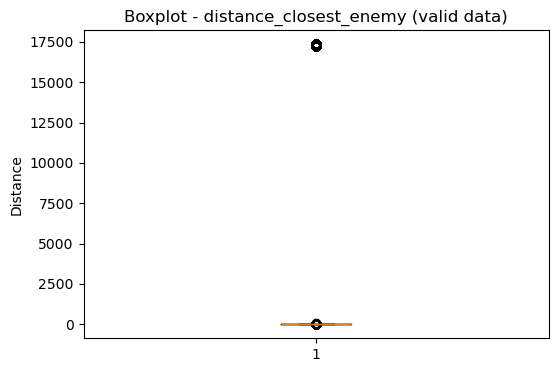

In [16]:
sample = spark.sql("""
SELECT distance_closest_enemy AS dist
FROM csgo TABLESAMPLE (1 PERCENT)
""").toPandas()

plt.figure(figsize=(6,4))
plt.boxplot(sample["dist"], vert=True, showfliers=True)
plt.title("Boxplot - distance_closest_enemy (valid data)")
plt.ylabel("Distance")
plt.show()

In [5]:
percentis = spark.sql("""
SELECT
    percentile_approx(distance_closest_enemy, 0.00) AS p0,
    percentile_approx(distance_closest_enemy, 0.05) AS p5,
    percentile_approx(distance_closest_enemy, 0.10) AS p10,
    percentile_approx(distance_closest_enemy, 0.15) AS p15,
    percentile_approx(distance_closest_enemy, 0.20) AS p20,
    percentile_approx(distance_closest_enemy, 0.25) AS p25,
    percentile_approx(distance_closest_enemy, 0.30) AS p30,
    percentile_approx(distance_closest_enemy, 0.35) AS p35,
    percentile_approx(distance_closest_enemy, 0.40) AS p40,
    percentile_approx(distance_closest_enemy, 0.45) AS p45,
    percentile_approx(distance_closest_enemy, 0.50) AS p50,
    percentile_approx(distance_closest_enemy, 0.55) AS p55,
    percentile_approx(distance_closest_enemy, 0.60) AS p60,
    percentile_approx(distance_closest_enemy, 0.65) AS p65,
    percentile_approx(distance_closest_enemy, 0.70) AS p70,
    percentile_approx(distance_closest_enemy, 0.75) AS p75,
    percentile_approx(distance_closest_enemy, 0.80) AS p80,
    percentile_approx(distance_closest_enemy, 0.85) AS p85,
    percentile_approx(distance_closest_enemy, 0.90) AS p90,
    percentile_approx(distance_closest_enemy, 0.95) AS p95,
    percentile_approx(distance_closest_enemy, 0.98) AS p98,
    percentile_approx(distance_closest_enemy, 0.99) AS p99,
    percentile_approx(distance_closest_enemy, 1.00) AS p100
FROM csgo
""").toPandas()

print(percentis)

    p0   p5  p10  p15  p20  p25  p30  p35  p40  p45  ...   p65   p70   p75  \
0  0.0  0.0  0.0  0.0  0.0  3.7  5.3  6.5  7.6  8.6  ...  13.3  14.8  16.7   

    p80   p85   p90      p95      p98      p99     p100  
0  19.2  22.9  29.4  17261.7  17321.6  17326.9  17352.8  

[1 rows x 23 columns]


#### Provavelmente em casos que IsAlive = 0 ou que todos os inimigos estão mortos, a distancia de inimigos vai as alturas por causa da maneira que o jogo computa a posição de um jogador morto. 

In [7]:
percentis = spark.sql("""
SELECT
    percentile_approx(distance_closest_enemy, 0.00) AS p0,
    percentile_approx(distance_closest_enemy, 0.05) AS p5,
    percentile_approx(distance_closest_enemy, 0.10) AS p10,
    percentile_approx(distance_closest_enemy, 0.15) AS p15,
    percentile_approx(distance_closest_enemy, 0.20) AS p20,
    percentile_approx(distance_closest_enemy, 0.25) AS p25,
    percentile_approx(distance_closest_enemy, 0.30) AS p30,
    percentile_approx(distance_closest_enemy, 0.35) AS p35,
    percentile_approx(distance_closest_enemy, 0.40) AS p40,
    percentile_approx(distance_closest_enemy, 0.45) AS p45,
    percentile_approx(distance_closest_enemy, 0.50) AS p50,
    percentile_approx(distance_closest_enemy, 0.55) AS p55,
    percentile_approx(distance_closest_enemy, 0.60) AS p60,
    percentile_approx(distance_closest_enemy, 0.65) AS p65,
    percentile_approx(distance_closest_enemy, 0.70) AS p70,
    percentile_approx(distance_closest_enemy, 0.75) AS p75,
    percentile_approx(distance_closest_enemy, 0.80) AS p80,
    percentile_approx(distance_closest_enemy, 0.85) AS p85,
    percentile_approx(distance_closest_enemy, 0.90) AS p90,
    percentile_approx(distance_closest_enemy, 0.95) AS p95,
    percentile_approx(distance_closest_enemy, 0.98) AS p98,
    percentile_approx(distance_closest_enemy, 0.99) AS p99,
    percentile_approx(distance_closest_enemy, 1.00) AS p100
FROM csgo
WHERE isAlive = 1
    AND num_enemy_alive > 0

""").toPandas()

print(percentis)

    p0   p5  p10  p15  p20  p25  p30  p35  p40   p45  ...   p65   p70   p75  \
0  0.3  3.9  5.0  6.0  6.8  7.6  8.4  9.1  9.8  10.7  ...  14.5  15.8  17.3   

    p80   p85   p90   p95   p98   p99  p100  
0  19.2  21.7  25.4  31.1  36.7  39.7  62.3  

[1 rows x 23 columns]


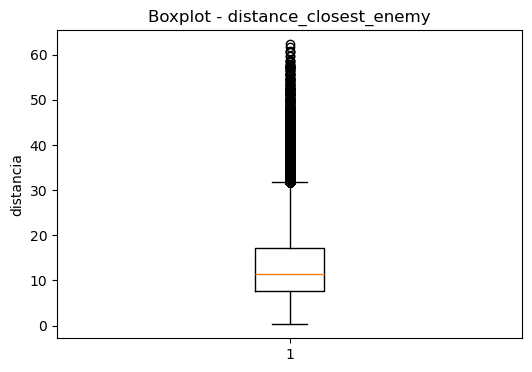

In [4]:
sample = spark.sql("""
    SELECT distance_closest_enemy AS dist
    FROM csgo
    WHERE isAlive = 1 
      AND num_enemy_alive > 0
      AND rand(42) <= 0.3
""").toPandas()

plt.figure(figsize=(6,4))
plt.boxplot(sample["dist"], vert=True, showfliers=True)
plt.title("Boxplot - distance_closest_enemy")
plt.ylabel("distancia")
plt.show()

In [ ]:
###

### Colunas que tratam do time oposto (5 jogadores possíveis)

In [10]:
spark.sql("""
SELECT
    num_enemy_alive,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY num_enemy_alive
ORDER BY num_enemy_alive
""").show()

spark.sql("""
SELECT
    num_team_alive,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY num_team_alive
ORDER BY num_team_alive
""").show()

spark.sql("""
SELECT
    enemy_in_range_200,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY enemy_in_range_200
ORDER BY enemy_in_range_200
""").show()

spark.sql("""
SELECT
    enemy_in_range_500,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY enemy_in_range_500
ORDER BY enemy_in_range_500
""").show()

spark.sql("""
SELECT
    enemy_in_range_1000,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY enemy_in_range_1000
ORDER BY enemy_in_range_1000
""").show()

spark.sql("""
SELECT
    enemy_in_range_2000,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY enemy_in_range_2000
ORDER BY enemy_in_range_2000
""").show()

spark.sql("""
SELECT
    team_in_range_200,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY team_in_range_200
ORDER BY team_in_range_200
""").show()

spark.sql("""
SELECT
    team_in_range_500,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY team_in_range_500
ORDER BY team_in_range_500
""").show()

spark.sql("""
SELECT
    team_in_range_1000,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo
GROUP BY team_in_range_1000
ORDER BY team_in_range_1000
""").show()

+---------------+-------+-----------+
|num_enemy_alive|  total|porcentagem|
+---------------+-------+-----------+
|              0| 620097|       3.24|
|              1|1595506|       8.33|
|              2|2086116|      10.90|
|              3|2638544|      13.78|
|              4|3463394|      18.09|
|              5|8740272|      45.66|
+---------------+-------+-----------+

+--------------+-------+-----------+
|num_team_alive|  total|porcentagem|
+--------------+-------+-----------+
|             0| 620395|       3.24|
|             1|1595492|       8.33|
|             2|2086801|      10.90|
|             3|2638194|      13.78|
|             4|3462413|      18.09|
|             5|8740634|      45.66|
+--------------+-------+-----------+

+------------------+--------+-----------+
|enemy_in_range_200|   total|porcentagem|
+------------------+--------+-----------+
|                 0|19072256|      99.63|
|                 1|   68746|       0.36|
|                 2|    2766|       0.

### Mapa

In [24]:
spark.sql("""
SELECT
    map,
    COUNT(DISTINCT match) AS total,
    ROUND(
        100.0 * COUNT(DISTINCT match) / SUM(COUNT(DISTINCT match)) OVER (),
        2
    ) AS porcentagem
FROM csgo
GROUP BY map
ORDER BY map
""").show(100, truncate=False)

+--------+-----+-----------+
|map     |total|porcentagem|
+--------+-----+-----------+
|2       |3    |0.36       |
|ancient |78   |9.39       |
|dust    |1    |0.12       |
|dust2   |116  |13.96      |
|inferno |147  |17.69      |
|mirage  |138  |16.61      |
|nuke    |143  |17.21      |
|overpass|113  |13.60      |
|p1      |1    |0.12       |
|p2      |2    |0.24       |
|vertigo |89   |10.71      |
+--------+-----+-----------+



#### Provavelmente "2", "dust", "p1" e "p2" são causados por inconsistência na nomenclatura das pastas, sendo "2" e "dust" o mapa "dust2" então podem ser unidas posteriormente, e "p1" e "p2" anomalias, mas como representam apenas 0.22% do dataset, podem ser deletadas sem muito impacto.

### Rounds

In [23]:
resultado = spark.sql("""
    SELECT AVG(max_round) as media_rounds_por_partida
    FROM (
        SELECT match, MAX(roundNum) as max_round
        FROM csgo
        GROUP BY match
    )
""").show()

+------------------------+
|media_rounds_por_partida|
+------------------------+
|       25.74757281553398|
+------------------------+



In [26]:
spark.sql("""
    SELECT 
        map_corrigido AS map, 
        ROUND(AVG(max_round), 2) AS media_rounds
    FROM (
        SELECT 
            match, 
            CASE 
                WHEN map IN ('2', 'dust') THEN 'dust2' 
                ELSE map 
            END AS map_corrigido, 
            MAX(roundNum) AS max_round
        FROM csgo
        WHERE map NOT IN ('p1', 'p2')
        GROUP BY match, map_corrigido
    )
    GROUP BY map_corrigido
    ORDER BY media_rounds DESC
""").show()

+--------+------------+
|     map|media_rounds|
+--------+------------+
|overpass|       26.58|
|   dust2|       26.03|
| inferno|       25.81|
| ancient|       25.72|
|  mirage|       25.49|
|    nuke|       25.28|
| vertigo|       25.19|
+--------+------------+



In [28]:
spark.sql("""
    SELECT 
        total_rounds, 
        COUNT(*) AS qtd_partidas
    FROM (
        SELECT 
            match, 
            MAX(roundNum) AS total_rounds
        FROM csgo
        WHERE map NOT IN ('p1', 'p2')
        GROUP BY match
    )
    GROUP BY total_rounds
    ORDER BY total_rounds ASC
""").show(100)

+------------+------------+
|total_rounds|qtd_partidas|
+------------+------------+
|          15|           1|
|          16|           8|
|          17|          11|
|          18|          17|
|          19|          23|
|          20|          47|
|          21|          49|
|          22|          41|
|          23|          72|
|          24|          60|
|          25|          66|
|          26|          85|
|          27|          89|
|          28|          82|
|          29|          69|
|          30|          27|
|          32|           2|
|          33|           8|
|          34|          18|
|          35|          19|
|          36|          11|
|          39|           1|
|          40|           5|
|          42|           2|
|          44|           1|
|          45|           1|
|          46|           1|
|          47|           3|
|          48|           1|
|          51|           1|
|          58|           1|
+------------+------------+



In [29]:
spark.sql("""
    SELECT 
        match, 
        MAX(roundNum) AS total_rounds
    FROM csgo
    WHERE map NOT IN ('p1', 'p2')
    GROUP BY match
    HAVING total_rounds > 30
    ORDER BY total_rounds DESC
""").show(truncate=False)


+-------------------------------+------------+
|match                          |total_rounds|
+-------------------------------+------------+
|galaxy-racer-vs-young-ninjas-m3|58          |
|detona-vs-leviatan             |51          |
|dignitas-vs-extremum-m2        |48          |
|9z-vs-havan-liberty-m1         |47          |
|aab-vs-mixala                  |47          |
|trasko-vs-ec-kyiv-m3           |47          |
|freedom-fighters-vs-levitate-m1|46          |
|tricked-vs-ec-kyiv-m3          |45          |
|liquid-vs-fnatic-m2            |44          |
|big-vs-skade-m1                |42          |
|bravos-vs-9z                   |42          |
|ldlc-vs-wisla-krakow-m1        |40          |
|entropiq-vs-nemiga-m3          |40          |
|opaa-vs-eternal-fire-m2        |40          |
|finest-vs-havu                 |40          |
|ceara-vs-havan-liberty-m1      |40          |
|offset-vs-nasr                 |39          |
|spirit-vs-skade-m1             |36          |
|fiend-vs-ska

#### Rounds acima de 30 indicam prorrogração na partida, mas para verificar se estão condizentes pesquisamos o nome das partidas. E os dados estão corretos.

### weapon_closest_enemy e active_weapon

In [62]:
spark.sql("""
SELECT
    activeWeapon AS categoria,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo_model
GROUP BY activeWeapon
ORDER BY total DESC
""").show(100, truncate=False)

spark.sql("""
SELECT
    weapon_closest_enemy AS categoria,
    COUNT(*) AS total,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentagem
FROM csgo_model
GROUP BY weapon_closest_enemy
ORDER BY total DESC
""").show(100, truncate=False)

+-------------------+-------+-----------+
|categoria          |total  |porcentagem|
+-------------------+-------+-----------+
|Assault Rifle Kills|5609207|39.37      |
|Melee Kills        |2723658|19.12      |
|Utility Kills      |2306702|16.19      |
|Pistol Kills       |1824072|12.80      |
|Sniper Rifle Kills |1374577|9.65       |
|SMG Kills          |394465 |2.77       |
|Shotgun Kills      |13381  |0.09       |
|Machine Gun Kills  |1052   |0.01       |
+-------------------+-------+-----------+

+-------------------+-------+-----------+
|categoria          |total  |porcentagem|
+-------------------+-------+-----------+
|Assault Rifle Kills|6032755|42.34      |
|Utility Kills      |2425631|17.03      |
|Melee Kills        |2126946|14.93      |
|Pistol Kills       |2083785|14.63      |
|Sniper Rifle Kills |1041497|7.31       |
|SMG Kills          |512459 |3.60       |
|Shotgun Kills      |22882  |0.16       |
|Machine Gun Kills  |1159   |0.01       |
+-------------------+-------+----

## Relações sobre "evento de morte"

### Para trabalhar com o evento de "morte" na EDA, criaremos uma view temporária do dataset com essa nova coluna, essa coluna será inserida no dataset após todas as análises e antes das implementações dos modelos. A coluna é baseada em linhas onde uma morte acontece em até 3 linhas (segundos), ao invés de apenas 1 linha antes de uma morte, pois o numero de eventos já é baixo e isso também perde contextos anteriores.

In [48]:
spark.sql("""
WITH base AS (
    SELECT
        *,
        LEAD(isAlive, 1) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_alive
    FROM csgo
)

SELECT
    *,
    CASE 
        WHEN isAlive = 1 AND next_alive = 0 THEN 1
        ELSE 0
    END AS death_event
FROM base
WHERE isAlive = 1
""").createOrReplaceTempView("csgo_model")

In [49]:
spark.sql("""
SELECT
    death_event,
    COUNT(*) AS total
FROM csgo_model
GROUP BY death_event

""").show()

+-----------+--------+
|death_event|   total|
+-----------+--------+
|          1|  167724|
|          0|14079390|
+-----------+--------+



### Diferença relativa dos valores das colunas em relação ao evento de morte (IsAlive = 0 não considerado nesse ponto, pois jogadores mortos não tem como morrer)

#### Informações de combate

In [13]:
spark.sql("""
SELECT * FROM (

    SELECT 'distance_closest_enemy' AS feature,
           AVG(CASE WHEN death_event = 1 THEN distance_closest_enemy END) AS death,
           AVG(CASE WHEN death_event = 0 THEN distance_closest_enemy END) AS normal,
           (AVG(CASE WHEN death_event = 1 THEN distance_closest_enemy END) -
            AVG(CASE WHEN death_event = 0 THEN distance_closest_enemy END)) /
            AVG(CASE WHEN death_event = 0 THEN distance_closest_enemy END) AS pct_diff
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'hp_closest_enemy',
           AVG(CASE WHEN death_event = 1 THEN hp_closest_enemy END),
           AVG(CASE WHEN death_event = 0 THEN hp_closest_enemy END),
           (AVG(CASE WHEN death_event = 1 THEN hp_closest_enemy END) -
            AVG(CASE WHEN death_event = 0 THEN hp_closest_enemy END)) /
            AVG(CASE WHEN death_event = 0 THEN hp_closest_enemy END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'num_enemy_alive',
           AVG(CASE WHEN death_event = 1 THEN num_enemy_alive END),
           AVG(CASE WHEN death_event = 0 THEN num_enemy_alive END),
           (AVG(CASE WHEN death_event = 1 THEN num_enemy_alive END) -
            AVG(CASE WHEN death_event = 0 THEN num_enemy_alive END)) /
            AVG(CASE WHEN death_event = 0 THEN num_enemy_alive END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'num_team_alive',
           AVG(CASE WHEN death_event = 1 THEN num_team_alive END),
           AVG(CASE WHEN death_event = 0 THEN num_team_alive END),
           (AVG(CASE WHEN death_event = 1 THEN num_team_alive END) -
            AVG(CASE WHEN death_event = 0 THEN num_team_alive END)) /
            AVG(CASE WHEN death_event = 0 THEN num_team_alive END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'total_hp_enemy',
           AVG(CASE WHEN death_event = 1 THEN total_hp_enemy END),
           AVG(CASE WHEN death_event = 0 THEN total_hp_enemy END),
           (AVG(CASE WHEN death_event = 1 THEN total_hp_enemy END) -
            AVG(CASE WHEN death_event = 0 THEN total_hp_enemy END)) /
            AVG(CASE WHEN death_event = 0 THEN total_hp_enemy END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'total_hp_team',
           AVG(CASE WHEN death_event = 1 THEN total_hp_team END),
           AVG(CASE WHEN death_event = 0 THEN total_hp_team END),
           (AVG(CASE WHEN death_event = 1 THEN total_hp_team END) -
            AVG(CASE WHEN death_event = 0 THEN total_hp_team END)) /
            AVG(CASE WHEN death_event = 0 THEN total_hp_team END)
    FROM csgo_model WHERE isAlive = 1

) t
ORDER BY pct_diff ASC
""").show(truncate=False)

+----------------------+------------------+------------------+--------------------+
|feature               |death             |normal            |pct_diff            |
+----------------------+------------------+------------------+--------------------+
|distance_closest_enemy|61.27945135850829 |434.1482060376633 |-0.8588513081332595 |
|total_hp_team         |312.0500236389828 |406.13935026104645|-0.23166759527631994|
|num_team_alive        |3.5669474501969924|4.342581343837959 |-0.17861125266923933|
|total_hp_enemy        |332.4737518506105 |381.8742611487899 |-0.1293632860972829 |
|num_enemy_alive       |3.6969986193915556|4.0436289030302275|-0.08572257542696685|
|hp_closest_enemy      |86.61968676613559 |90.06612243548912 |-0.03826561615131241|
+----------------------+------------------+------------------+--------------------+



#### Economia

In [14]:
spark.sql("""
SELECT * FROM (

    SELECT 'equipmentValue' AS feature,
           AVG(CASE WHEN death_event = 1 THEN equipmentValue END) AS death,
           AVG(CASE WHEN death_event = 0 THEN equipmentValue END) AS normal,
           (AVG(CASE WHEN death_event = 1 THEN equipmentValue END) -
            AVG(CASE WHEN death_event = 0 THEN equipmentValue END)) /
            AVG(CASE WHEN death_event = 0 THEN equipmentValue END) AS pct_diff
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'equipment_value_enemy',
           AVG(CASE WHEN death_event = 1 THEN equipment_value_enemy END),
           AVG(CASE WHEN death_event = 0 THEN equipment_value_enemy END),
           (AVG(CASE WHEN death_event = 1 THEN equipment_value_enemy END) -
            AVG(CASE WHEN death_event = 0 THEN equipment_value_enemy END)) /
            AVG(CASE WHEN death_event = 0 THEN equipment_value_enemy END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'equipment_value_team',
           AVG(CASE WHEN death_event = 1 THEN equipment_value_team END),
           AVG(CASE WHEN death_event = 0 THEN equipment_value_team END),
           (AVG(CASE WHEN death_event = 1 THEN equipment_value_team END) -
            AVG(CASE WHEN death_event = 0 THEN equipment_value_team END)) /
            AVG(CASE WHEN death_event = 0 THEN equipment_value_team END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'cash',
           AVG(CASE WHEN death_event = 1 THEN cash END),
           AVG(CASE WHEN death_event = 0 THEN cash END),
           (AVG(CASE WHEN death_event = 1 THEN cash END) -
            AVG(CASE WHEN death_event = 0 THEN cash END)) /
            AVG(CASE WHEN death_event = 0 THEN cash END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'armor',
           AVG(CASE WHEN death_event = 1 THEN armor END),
           AVG(CASE WHEN death_event = 0 THEN armor END),
           (AVG(CASE WHEN death_event = 1 THEN armor END) -
            AVG(CASE WHEN death_event = 0 THEN armor END)) /
            AVG(CASE WHEN death_event = 0 THEN armor END)
    FROM csgo_model WHERE isAlive = 1

) t
ORDER BY pct_diff ASC
""").show(truncate=False)

+---------------------+------------------+------------------+---------------------+
|feature              |death             |normal            |pct_diff             |
+---------------------+------------------+------------------+---------------------+
|equipment_value_team |14716.039687472254|19515.82073807492 |-0.24594307946467261 |
|equipmentValue       |4036.9305671466873|4506.403250864091 |-0.10417902206762872 |
|armor                |81.17752439381698 |87.96957117664583 |-0.07720904731012262 |
|equipment_value_enemy|17116.743135048266|17830.852638994198|-0.04004909458924303 |
|cash                 |1981.2498335271816|2044.278937766506 |-0.030831949141044014|
+---------------------+------------------+------------------+---------------------+



#### Condições

In [15]:
spark.sql("""
SELECT * FROM (

    SELECT 'isBlinded' AS feature,
           AVG(CASE WHEN isBlinded = 1 THEN death_event END) AS prob_1,
           AVG(CASE WHEN isBlinded = 0 THEN death_event END) AS prob_0,
           (AVG(CASE WHEN isBlinded = 1 THEN death_event END) -
            AVG(CASE WHEN isBlinded = 0 THEN death_event END)) /
            AVG(CASE WHEN isBlinded = 0 THEN death_event END) AS pct_diff
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'isAirborne',
           AVG(CASE WHEN isAirborne = 1 THEN death_event END),
           AVG(CASE WHEN isAirborne = 0 THEN death_event END),
           (AVG(CASE WHEN isAirborne = 1 THEN death_event END) -
            AVG(CASE WHEN isAirborne = 0 THEN death_event END)) /
            AVG(CASE WHEN isAirborne = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'isDucking',
           AVG(CASE WHEN isDucking = 1 THEN death_event END),
           AVG(CASE WHEN isDucking = 0 THEN death_event END),
           (AVG(CASE WHEN isDucking = 1 THEN death_event END) -
            AVG(CASE WHEN isDucking = 0 THEN death_event END)) /
            AVG(CASE WHEN isDucking = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'isStanding',
           AVG(CASE WHEN isStanding = 1 THEN death_event END),
           AVG(CASE WHEN isStanding = 0 THEN death_event END),
           (AVG(CASE WHEN isStanding = 1 THEN death_event END) -
            AVG(CASE WHEN isStanding = 0 THEN death_event END)) /
            AVG(CASE WHEN isStanding = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'isScoped',
           AVG(CASE WHEN isScoped = 1 THEN death_event END),
           AVG(CASE WHEN isScoped = 0 THEN death_event END),
           (AVG(CASE WHEN isScoped = 1 THEN death_event END) -
            AVG(CASE WHEN isScoped = 0 THEN death_event END)) /
            AVG(CASE WHEN isScoped = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'isWalking',
           AVG(CASE WHEN isWalking = 1 THEN death_event END),
           AVG(CASE WHEN isWalking = 0 THEN death_event END),
           (AVG(CASE WHEN isWalking = 1 THEN death_event END) -
            AVG(CASE WHEN isWalking = 0 THEN death_event END)) /
            AVG(CASE WHEN isWalking = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'hasHelmet',
           AVG(CASE WHEN hasHelmet = 1 THEN death_event END),
           AVG(CASE WHEN hasHelmet = 0 THEN death_event END),
           (AVG(CASE WHEN hasHelmet = 1 THEN death_event END) -
            AVG(CASE WHEN hasHelmet = 0 THEN death_event END)) /
            AVG(CASE WHEN hasHelmet = 0 THEN death_event END)
    FROM csgo_model WHERE isAlive = 1

) t
ORDER BY pct_diff DESC
""").show(truncate=False)

+----------+--------------------+--------------------+--------------------+
|feature   |prob_1              |prob_0              |pct_diff            |
+----------+--------------------+--------------------+--------------------+
|isBlinded |0.10139918667966404 |0.029574207647809627|2.4286357858576144  |
|isDucking |0.03600770297631239 |0.031123369031429732|0.15693461527093172 |
|isStanding|0.030409085059185197|0.041023250786960105|-0.2587353640718495 |
|isAirborne|0.02352258237929543 |0.03215961002470725 |-0.26856754913309755|
|hasHelmet |0.028541243421189747|0.03906450032172965 |-0.26938158209811625|
|isScoped  |0.022482297382201234|0.03225194386239007 |-0.30291651634621325|
|isWalking |0.021241475851848074|0.03601281613362657 |-0.4101689861456272 |
+----------+--------------------+--------------------+--------------------+



#### Performance na partida

In [16]:
spark.sql("""
SELECT * FROM (

    SELECT 'kills_from_avg' AS feature,
           AVG(CASE WHEN death_event = 1 THEN kills_from_avg END) AS death,
           AVG(CASE WHEN death_event = 0 THEN kills_from_avg END) AS normal,
           (AVG(CASE WHEN death_event = 1 THEN kills_from_avg END) -
            AVG(CASE WHEN death_event = 0 THEN kills_from_avg END)) /
            NULLIF(AVG(CASE WHEN death_event = 0 THEN kills_from_avg END), 0) AS pct_diff
    FROM csgo_model
    WHERE isAlive = 1

    UNION ALL

    SELECT 'deaths_from_avg',
           AVG(CASE WHEN death_event = 1 THEN deaths_from_avg END),
           AVG(CASE WHEN death_event = 0 THEN deaths_from_avg END),
           (AVG(CASE WHEN death_event = 1 THEN deaths_from_avg END) -
            AVG(CASE WHEN death_event = 0 THEN deaths_from_avg END)) /
            NULLIF(AVG(CASE WHEN death_event = 0 THEN deaths_from_avg END), 0)
    FROM csgo_model
    WHERE isAlive = 1

) t
ORDER BY pct_diff DESC
""").show(truncate=False)

+---------------+--------------------+--------------------+-------------------+
|feature        |death               |normal              |pct_diff           |
+---------------+--------------------+--------------------+-------------------+
|kills_from_avg |0.024109063627848277|0.019520616981527582|0.23505643549395774|
|deaths_from_avg|-0.05009195938072065|-0.11883150393189654|-0.5784622955758532|
+---------------+--------------------+--------------------+-------------------+



#### Tipo de arma carregada por jogador x inimigo

In [17]:
spark.sql("""
WITH base_counts AS (
    SELECT 
        CAST(SUM(death_event) AS DOUBLE) AS total_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS total_normal
    FROM csgo_model
    WHERE isAlive = 1
),

weapon_stats AS (
    SELECT 
        activeWeapon,
        CAST(SUM(death_event) AS DOUBLE) AS count_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS count_normal
    FROM csgo_model
    WHERE isAlive = 1
    GROUP BY activeWeapon
)

SELECT 
    activeWeapon,
    count_death / total_death AS death,
    count_normal / total_normal AS normal,
    ((count_death / total_death) - (count_normal / total_normal)) /
    (count_normal / total_normal) AS pct_diff

FROM weapon_stats
CROSS JOIN base_counts

WHERE count_normal > 0
ORDER BY pct_diff DESC
""").show(truncate=False)

spark.sql("""
WITH base_counts AS (
    SELECT 
        CAST(SUM(death_event) AS DOUBLE) AS total_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS total_normal
    FROM csgo_model
    WHERE isAlive = 1
),

weapon_stats AS (
    SELECT 
        weapon_closest_enemy,
        CAST(SUM(death_event) AS DOUBLE) AS count_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS count_normal
    FROM csgo_model
    WHERE isAlive = 1
    GROUP BY weapon_closest_enemy
)

SELECT 
    weapon_closest_enemy,
    count_death / total_death AS death,
    count_normal / total_normal AS normal,
    ((count_death / total_death) - (count_normal / total_normal)) /
    (count_normal / total_normal) AS pct_diff

FROM weapon_stats
CROSS JOIN base_counts

WHERE count_normal > 0
ORDER BY pct_diff DESC
""").show(truncate=False)

+-------------------+---------------------+--------------------+--------------------+
|activeWeapon       |death                |normal              |pct_diff            |
+-------------------+---------------------+--------------------+--------------------+
|Pistol Kills       |0.23313253814294782  |0.12459877714551122 |0.8710660207418145  |
|Shotgun Kills      |0.0015248300935317906|9.200836265704263E-4|0.6572733711342432  |
|SMG Kills          |0.03893532678418438  |0.027320047327698504|0.4251559053746476  |
|Machine Gun Kills  |9.987970044968061E-5 |7.298914541960133E-5|0.3684185487511926  |
|Assault Rifle Kills|0.49442449316600895  |0.3904193012583126  |0.2663935711489928  |
|Sniper Rifle Kills |0.08879749279756383  |0.09673199980400929 |-0.08202566909111496|
|Utility Kills      |0.10769695167154228  |0.16367689017242834 |-0.3420149200165826 |
|Melee Kills        |0.0353618530569847   |0.19626078130132615 |-0.8198221120770309 |
+-------------------+---------------------+-----------

##### Comparação das combinações entre tipo de arma carregada pelo jogador x tipo de arma carregada pelo inimigo

In [18]:
spark.sql("""
WITH base_counts AS (
    SELECT 
        CAST(SUM(death_event) AS DOUBLE) AS total_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS total_normal
    FROM csgo_model
    WHERE isAlive = 1
),

combo_stats AS (
    SELECT 
        activeWeapon,
        weapon_closest_enemy,
        CAST(SUM(death_event) AS DOUBLE) AS count_death,
        CAST(SUM(1 - death_event) AS DOUBLE) AS count_normal,
        COUNT(*) AS total
    FROM csgo_model
    WHERE isAlive = 1
    GROUP BY activeWeapon, weapon_closest_enemy
)

SELECT
    activeWeapon,
    weapon_closest_enemy,
    total,

    count_death / total_death AS death,
    count_normal / total_normal AS normal,

    ((count_death / total_death) - (count_normal / total_normal)) /
    (count_normal / total_normal) AS pct_diff

FROM combo_stats
CROSS JOIN base_counts

WHERE count_normal > 0
  AND total > 10000   -- pra evitar combinações destoantes
ORDER BY pct_diff DESC
""").show(100, truncate=False)

+-------------------+--------------------+-------+---------------------+---------------------+---------------------+
|activeWeapon       |weapon_closest_enemy|total  |death                |normal               |pct_diff             |
+-------------------+--------------------+-------+---------------------+---------------------+---------------------+
|Pistol Kills       |SMG Kills           |140694 |0.021611747628412    |0.009491995547879575 |1.276839208299025    |
|Pistol Kills       |Assault Rifle Kills |748263 |0.11240461488607055  |0.05056473448621875  |1.2229843788996073   |
|Pistol Kills       |Pistol Kills        |448663 |0.06414718272658265  |0.030425094001611416 |1.1083643233176272   |
|SMG Kills          |SMG Kills           |20325  |0.0028632180795575106|0.0013796905492175883|1.0752610657376895   |
|Pistol Kills       |Sniper Rifle Kills  |70363  |0.009497449738315185 |0.00478988548749646  |0.982813527193369    |
|SMG Kills          |Assault Rifle Kills |147194 |0.018786261880

#### Colunas baseadas em distancia

In [19]:
spark.sql("""
SELECT * FROM (

    SELECT 'enemy_in_range_200' AS feature,
           AVG(CASE WHEN death_event = 1 THEN enemy_in_range_200 END) AS death,
           AVG(CASE WHEN death_event = 0 THEN enemy_in_range_200 END) AS normal,
           (AVG(CASE WHEN death_event = 1 THEN enemy_in_range_200 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_200 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_200 END) AS pct_diff
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_in_range_500',
           AVG(CASE WHEN death_event = 1 THEN enemy_in_range_500 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_in_range_500 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_in_range_500 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_500 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_500 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_in_range_1000',
           AVG(CASE WHEN death_event = 1 THEN enemy_in_range_1000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_in_range_1000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_in_range_1000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_1000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_1000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_in_range_2000',
           AVG(CASE WHEN death_event = 1 THEN enemy_in_range_2000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_in_range_2000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_in_range_2000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_2000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_in_range_2000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_hp_in_range_500',
           AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_500 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_500 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_500 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_500 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_500 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_hp_in_range_1000',
           AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_1000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_1000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_1000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_1000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_1000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_hp_in_range_2000',
           AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_2000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_2000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_hp_in_range_2000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_2000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_hp_in_range_2000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_equipment_in_range_500',
           AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_500 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_500 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_500 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_500 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_500 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_equipment_in_range_1000',
           AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_1000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_1000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_1000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_1000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_1000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'enemy_equipment_in_range_2000',
           AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_2000 END),
           AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_2000 END),
           (AVG(CASE WHEN death_event = 1 THEN enemy_equipment_in_range_2000 END) -
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_2000 END)) /
            AVG(CASE WHEN death_event = 0 THEN enemy_equipment_in_range_2000 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'team_in_range_200',
           AVG(CASE WHEN death_event = 1 THEN team_in_range_200 END),
           AVG(CASE WHEN death_event = 0 THEN team_in_range_200 END),
           (AVG(CASE WHEN death_event = 1 THEN team_in_range_200 END) -
            AVG(CASE WHEN death_event = 0 THEN team_in_range_200 END)) /
            AVG(CASE WHEN death_event = 0 THEN team_in_range_200 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'team_in_range_500',
           AVG(CASE WHEN death_event = 1 THEN team_in_range_500 END),
           AVG(CASE WHEN death_event = 0 THEN team_in_range_500 END),
           (AVG(CASE WHEN death_event = 1 THEN team_in_range_500 END) -
            AVG(CASE WHEN death_event = 0 THEN team_in_range_500 END)) /
            AVG(CASE WHEN death_event = 0 THEN team_in_range_500 END)
    FROM csgo_model WHERE isAlive = 1

    UNION ALL

    SELECT 'team_in_range_1000',
           AVG(CASE WHEN death_event = 1 THEN team_in_range_1000 END),
           AVG(CASE WHEN death_event = 0 THEN team_in_range_1000 END),
           (AVG(CASE WHEN death_event = 1 THEN team_in_range_1000 END) -
            AVG(CASE WHEN death_event = 0 THEN team_in_range_1000 END)) /
            AVG(CASE WHEN death_event = 0 THEN team_in_range_1000 END)
    FROM csgo_model WHERE isAlive = 1

) t
ORDER BY pct_diff DESC
""").show(truncate=False)

+-----------------------------+-------------------+--------------------+--------------------+
|feature                      |death              |normal              |pct_diff            |
+-----------------------------+-------------------+--------------------+--------------------+
|enemy_in_range_200           |0.04008860734206829|0.004111016731891735|8.751506733377127   |
|enemy_in_range_500           |0.49821654891672273|0.10748255564439398 |3.6353247364630232  |
|enemy_equipment_in_range_500 |1622.2317401514667 |373.17833355923455  |3.347068396707898   |
|enemy_hp_in_range_500        |32.407603183552204 |7.820923143569064   |3.143705619994503   |
|enemy_in_range_1000          |1.7161194235246853 |0.669000432933285   |1.5651992719948247  |
|enemy_equipment_in_range_1000|3824.095161042111  |1681.4542449136563  |1.2742784542665213  |
|enemy_hp_in_range_1000       |73.88992676675745  |34.98834465859675   |1.1118440294260237  |
|enemy_in_range_2000          |3.1162301340673    |2.3613324

### diversos

In [46]:
spark.sql("""
SELECT * FROM (

    SELECT 'distance_closest_enemy' AS feature,
        (AVG(distance_closest_enemy * death_event)
        - AVG(distance_closest_enemy) * AVG(death_event)) /
        (STDDEV(distance_closest_enemy) * STDDEV(death_event)) AS corr
    FROM csgo_model

    UNION ALL

    SELECT 'hp',
        (AVG(hp * death_event)
        - AVG(hp) * AVG(death_event)) /
        (STDDEV(hp) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'armor',
        (AVG(armor * death_event)
        - AVG(armor) * AVG(death_event)) /
        (STDDEV(armor) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'total_hp_team',
        (AVG(total_hp_team * death_event)
        - AVG(total_hp_team) * AVG(death_event)) /
        (STDDEV(total_hp_team) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'total_hp_enemy',
        (AVG(total_hp_enemy * death_event)
        - AVG(total_hp_enemy) * AVG(death_event)) /
        (STDDEV(total_hp_enemy) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'num_enemy_alive',
        (AVG(num_enemy_alive * death_event)
        - AVG(num_enemy_alive) * AVG(death_event)) /
        (STDDEV(num_enemy_alive) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'num_team_alive',
        (AVG(num_team_alive * death_event)
        - AVG(num_team_alive) * AVG(death_event)) /
        (STDDEV(num_team_alive) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'hp_closest_enemy',
        (AVG(hp_closest_enemy * death_event)
        - AVG(hp_closest_enemy) * AVG(death_event)) /
        (STDDEV(hp_closest_enemy) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'kills_from_avg',
        (AVG(kills_from_avg * death_event)
        - AVG(kills_from_avg) * AVG(death_event)) /
        (STDDEV(kills_from_avg) * STDDEV(death_event))
    FROM csgo_model

    UNION ALL

    SELECT 'deaths_from_avg',
        (AVG(deaths_from_avg * death_event)
        - AVG(deaths_from_avg) * AVG(death_event)) /
        (STDDEV(deaths_from_avg) * STDDEV(death_event))
    FROM csgo_model

) t
ORDER BY corr DESC
""").show(truncate=False)

+----------------------+---------------------+
|feature               |corr                 |
+----------------------+---------------------+
|deaths_from_avg       |0.013018021986098534 |
|kills_from_avg        |8.513840916866501E-4 |
|distance_closest_enemy|-0.024826994556200504|
|hp_closest_enemy      |-0.02506208720519612 |
|armor                 |-0.04234391445636577 |
|num_enemy_alive       |-0.044201495147599974|
|total_hp_enemy        |-0.05932269711550232 |
|hp                    |-0.10867911295850637 |
|num_team_alive        |-0.13187483718479184 |
|total_hp_team         |-0.13831449160426734 |
+----------------------+---------------------+



In [30]:
spark.sql("""
SELECT
    isBlinded,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY isBlinded, enemy_in_range_200
ORDER BY prob DESC
""").show(truncate=False)

+---------+------------------+--------+--------------------+
|isBlinded|enemy_in_range_200|n       |prob                |
+---------+------------------+--------+--------------------+
|1        |3                 |27      |0.8148148148148148  |
|0        |5                 |5       |0.8                 |
|1        |2                 |388     |0.5077319587628866  |
|1        |1                 |5448    |0.44383259911894274 |
|0        |3                 |121     |0.4214876033057851  |
|0        |4                 |8       |0.375               |
|0        |2                 |2378    |0.2729184188393608  |
|0        |1                 |63298   |0.21643653827925052 |
|1        |0                 |400373  |0.09629770239251897 |
|0        |0                 |13775068|0.028669695133265404|
+---------+------------------+--------+--------------------+



In [32]:
spark.sql("""
SELECT
    activeWeapon,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY activeWeapon, enemy_in_range_200
ORDER BY prob DESC
""").show(40, truncate=False)

+-------------------+------------------+-------+---------------------+
|activeWeapon       |enemy_in_range_200|n      |prob                 |
+-------------------+------------------+-------+---------------------+
|Melee Kills        |5                 |4      |1.0                  |
|Shotgun Kills      |2                 |20     |0.8                  |
|Utility Kills      |3                 |19     |0.6842105263157895   |
|Sniper Rifle Kills |3                 |3      |0.6666666666666666   |
|Assault Rifle Kills|3                 |54     |0.48148148148148145  |
|SMG Kills          |3                 |23     |0.4782608695652174   |
|Pistol Kills       |3                 |32     |0.46875              |
|Melee Kills        |4                 |7      |0.42857142857142855  |
|Pistol Kills       |2                 |593    |0.38617200674536256  |
|Machine Gun Kills  |1                 |8      |0.375                |
|Melee Kills        |3                 |17     |0.35294117647058826  |
|Utili

In [33]:
spark.sql("""
SELECT
    hasHelmet,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY hasHelmet, enemy_in_range_200
ORDER BY prob DESC
""").show(truncate=False)

+---------+------------------+--------+--------------------+
|hasHelmet|enemy_in_range_200|n       |prob                |
+---------+------------------+--------+--------------------+
|0        |5                 |3       |1.0                 |
|1        |4                 |4       |0.75                |
|0        |3                 |66      |0.5303030303030303  |
|1        |5                 |2       |0.5                 |
|1        |3                 |82      |0.4634146341463415  |
|0        |2                 |956     |0.36506276150627615 |
|0        |1                 |20739   |0.27773759583393604 |
|1        |2                 |1810    |0.274585635359116   |
|1        |1                 |48007   |0.21576020163726123 |
|0        |0                 |4149436 |0.0377880270957306  |
|1        |0                 |10026005|0.027596435469561406|
|0        |4                 |4       |0.0                 |
+---------+------------------+--------+--------------------+



In [44]:
spark.sql("""
SELECT
    isWalking,
    isAirborne,
    isStanding,
    isDucking,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY isWalking, isAirborne, isStanding, isDucking, enemy_in_range_200
ORDER BY prob DESC
""").show(50, truncate=False)

+---------+----------+----------+---------+------------------+-------+--------------------+
|isWalking|isAirborne|isStanding|isDucking|enemy_in_range_200|n      |prob                |
+---------+----------+----------+---------+------------------+-------+--------------------+
|0        |0         |0         |0        |3                 |2      |1.0                 |
|0        |0         |1         |0        |5                 |4      |1.0                 |
|0        |1         |0         |1        |3                 |1      |1.0                 |
|0        |1         |1         |0        |3                 |3      |0.6666666666666666  |
|0        |0         |1         |0        |3                 |76     |0.6578947368421053  |
|0        |0         |0         |0        |2                 |59     |0.4745762711864407  |
|0        |1         |1         |0        |2                 |71     |0.4647887323943662  |
|0        |1         |0         |1        |2                 |21     |0.42857142

In [37]:
spark.sql("""
SELECT
    num_enemy_alive,
    num_team_alive,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY num_enemy_alive, num_team_alive
ORDER BY prob DESC
""").show(40,truncate=False)

+---------------+--------------+-------+---------------------+
|num_enemy_alive|num_team_alive|n      |prob                 |
+---------------+--------------+-------+---------------------+
|5              |1             |29866  |0.17270474787383647  |
|4              |1             |60683  |0.1582156452383699   |
|2              |1             |71416  |0.1497143497255517   |
|3              |1             |81551  |0.1455898762737428   |
|1              |1             |52998  |0.1224574512245745   |
|5              |2             |90025  |0.10608164398778117  |
|4              |2             |175374 |0.09036687308266904  |
|3              |2             |194127 |0.08687611718102067  |
|2              |2             |166347 |0.08225576656026258  |
|5              |3             |257446 |0.07104014045663945  |
|4              |3             |357381 |0.06501464823255854  |
|3              |3             |334171 |0.062303431476699055 |
|1              |2             |142881 |0.0532401089018

In [45]:
spark.sql("""
SELECT
    CASE
        WHEN kills_from_avg < -0.2 THEN 'low'
        WHEN kills_from_avg < 0.2 THEN 'mid'
        ELSE 'high'
    END AS perf,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY perf, enemy_in_range_200
ORDER BY prob DESC
""").show(truncate=False)

+----+------------------+-------+--------------------+
|perf|enemy_in_range_200|n      |prob                |
+----+------------------+-------+--------------------+
|low |5                 |4      |1.0                 |
|high|3                 |59     |0.5423728813559322  |
|mid |4                 |2      |0.5                 |
|low |3                 |66     |0.4696969696969697  |
|mid |3                 |23     |0.43478260869565216 |
|low |4                 |5      |0.4                 |
|low |2                 |1178   |0.34295415959252973 |
|mid |2                 |486    |0.29012345679012347 |
|high|2                 |1102   |0.2731397459165154  |
|low |1                 |30419  |0.24182254511982643 |
|high|1                 |27174  |0.22918966659306692 |
|mid |1                 |11153  |0.2272034430198153  |
|low |0                 |6293187|0.030916132001162527|
|high|0                 |5576519|0.030818688145776964|
|mid |0                 |2305735|0.02908356771268164 |
|high|4   

In [56]:
spark.sql("""
SELECT
    isScoped,
    enemy_in_range_200,
    COUNT(*) as n,
    AVG(death_event) AS prob
FROM csgo_model
GROUP BY isScoped, enemy_in_range_200
ORDER BY prob DESC
""").show(truncate=False)

+--------+------------------+--------+--------------------+
|isScoped|enemy_in_range_200|n       |prob                |
+--------+------------------+--------+--------------------+
|0       |5                 |5       |0.8                 |
|0       |3                 |147     |0.4965986394557823  |
|0       |4                 |8       |0.375               |
|0       |2                 |2741    |0.30682232761765776 |
|0       |1                 |67672   |0.23506029081451707 |
|1       |2                 |25      |0.2                 |
|1       |1                 |1074    |0.1973929236499069  |
|0       |0                 |13258174|0.031154063900503945|
|1       |0                 |917267  |0.022275956727975606|
|1       |3                 |1       |0.0                 |
+--------+------------------+--------+--------------------+



## CONFLITOS

### Para trabalhar com os eventos de confronto letais, criaremos uma view temporária do dataset contendo a coluna `res_conflito`, responsável por identificar situações de sucesso ou falha durante combates letais. Foram usadas comparações temporais entre ticks consecutivos para detectar mudanças no estado dos jogadores, como mortes, dano recebido e redução no número de inimigos vivos. Além disso, os jogadores são ranqueados dentro do próprio time com base na variação de `kills_from_avg`, permitindo inferir quais players provavelmente participaram com sucesso do confronto.

In [8]:
spark.sql("""

CREATE OR REPLACE TEMP VIEW conflitos_letais AS

WITH ordered AS (

    SELECT
        *,

        CASE
            WHEN player BETWEEN 1 AND 5 THEN 1
            ELSE 2
        END AS team_id,

        LEAD(hp) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_hp,

        LEAD(armor) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_armor,

        LEAD(isAlive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_isAlive,

        LEAD(isDead) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_isDead,

        LEAD(num_enemy_alive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_num_enemy_alive,

        LEAD(num_team_alive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_num_team_alive,

        LEAD(kills_from_avg) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_kills_from_avg

    FROM csgo
),

base_conflitos AS (

    SELECT
        *,

        (next_hp - hp) AS delta_hp,
        (next_armor - armor) AS delta_armor,

        (next_num_enemy_alive - num_enemy_alive) AS delta_enemy_alive,
        (next_num_team_alive - num_team_alive) AS delta_team_alive,

        (next_kills_from_avg - kills_from_avg) AS delta_kills,

        (kills_from_avg - deaths_from_avg) AS performance_score,

        ABS(next_num_enemy_alive - num_enemy_alive)
            AS inimigos_mortos

    FROM ordered

    WHERE

        next_hp IS NOT NULL

        AND NOT (
            isAlive = 0
            AND next_isAlive = 0
        )

        AND (

            next_hp < hp

            OR next_armor < armor

            OR next_num_enemy_alive < num_enemy_alive

            OR next_num_team_alive < num_team_alive

        )
),

eventos_morte AS (

    SELECT
        *,

        ROW_NUMBER() OVER (

            PARTITION BY
                match,
                roundNum,
                tick,
                team_id

            ORDER BY
                delta_kills DESC

        ) AS delta_rank

    FROM base_conflitos

    WHERE

        next_num_enemy_alive < num_enemy_alive
        OR next_num_team_alive < num_team_alive
),

success_rows AS (

    SELECT

        tick,
        kills_from_avg,
        deaths_from_avg,
        distance_closest_enemy,
        isBlinded,
        isAirborne,
        isDucking,
        isStanding,
        isScoped,
        isWalking,
        hasHelmet,
        hp,
        armor,
        equipmentValue,
        cash,
        total_hp_enemy,
        total_hp_team,
        num_enemy_alive,
        num_team_alive,
        enemy_in_range_200,
        enemy_in_range_500,
        enemy_in_range_1000,
        enemy_in_range_2000,
        enemy_hp_in_range_500,
        enemy_hp_in_range_1000,
        enemy_hp_in_range_2000,
        enemy_equipment_in_range_500,
        enemy_equipment_in_range_1000,
        enemy_equipment_in_range_2000,
        team_in_range_200,
        team_in_range_500,
        team_in_range_1000,
        equipment_value_team,
        equipment_value_enemy,
        hp_closest_enemy,
        activeWeapon,
        weapon_closest_enemy,
        isAlive,
        isDead,
        roundNum,
        player,
        match,
        map,

        team_id,

        next_hp,
        next_armor,
        next_isAlive,
        next_isDead,
        next_num_enemy_alive,
        next_num_team_alive,
        next_kills_from_avg,

        delta_hp,
        delta_armor,
        delta_enemy_alive,
        delta_team_alive,
        delta_kills,
        performance_score,

        inimigos_mortos,
        delta_rank,

        'Sucesso' AS res_conflito

    FROM eventos_morte

    WHERE

        next_isAlive = 1

        AND inimigos_mortos > 0

        AND delta_rank <= inimigos_mortos

),

failure_rows AS (

    SELECT

        tick,
        kills_from_avg,
        deaths_from_avg,
        distance_closest_enemy,
        isBlinded,
        isAirborne,
        isDucking,
        isStanding,
        isScoped,
        isWalking,
        hasHelmet,
        hp,
        armor,
        equipmentValue,
        cash,
        total_hp_enemy,
        total_hp_team,
        num_enemy_alive,
        num_team_alive,
        enemy_in_range_200,
        enemy_in_range_500,
        enemy_in_range_1000,
        enemy_in_range_2000,
        enemy_hp_in_range_500,
        enemy_hp_in_range_1000,
        enemy_hp_in_range_2000,
        enemy_equipment_in_range_500,
        enemy_equipment_in_range_1000,
        enemy_equipment_in_range_2000,
        team_in_range_200,
        team_in_range_500,
        team_in_range_1000,
        equipment_value_team,
        equipment_value_enemy,
        hp_closest_enemy,
        activeWeapon,
        weapon_closest_enemy,
        isAlive,
        isDead,
        roundNum,
        player,
        match,
        map,

        team_id,

        next_hp,
        next_armor,
        next_isAlive,
        next_isDead,
        next_num_enemy_alive,
        next_num_team_alive,
        next_kills_from_avg,

        delta_hp,
        delta_armor,
        delta_enemy_alive,
        delta_team_alive,
        delta_kills,
        performance_score,

        inimigos_mortos,
        delta_rank,

        'Falha' AS res_conflito

    FROM eventos_morte

    WHERE

        next_isAlive = 0
        OR next_isDead = 1

)

SELECT *
FROM success_rows

UNION ALL

SELECT *
FROM failure_rows

""")

DataFrame[]

In [10]:
# distribuição geral

spark.sql("""

SELECT
    res_conflito,
    COUNT(*) AS total
FROM conflitos_letais
GROUP BY res_conflito

""").show()

# distribuição por time

spark.sql("""

SELECT
    team_id,
    res_conflito,
    COUNT(*) AS total
FROM conflitos_letais
GROUP BY
    team_id,
    res_conflito
ORDER BY
    team_id,
    res_conflito

""").show()

+------------+------+
|res_conflito| total|
+------------+------+
|     Sucesso|151129|
|       Falha|164772|
+------------+------+

+-------+------------+-----+
|team_id|res_conflito|total|
+-------+------------+-----+
|      1|       Falha|81086|
|      1|     Sucesso|77218|
|      2|       Falha|83690|
|      2|     Sucesso|73911|
+-------+------------+-----+



In [11]:
# distribuição geral

spark.sql("""

SELECT
    res_conflito,
    COUNT(*) AS total
FROM conflitos_letais
GROUP BY res_conflito

""").show()

# distribuição por time

spark.sql("""

SELECT
    team_id,
    res_conflito,
    COUNT(*) AS total
FROM conflitos_letais
GROUP BY
    team_id,
    res_conflito
ORDER BY
    team_id,
    res_conflito

""").show()

# sucesso por rank

spark.sql("""

SELECT
    delta_rank,
    COUNT(*) AS sucessos
FROM conflitos_letais
WHERE res_conflito = 'Sucesso'
GROUP BY delta_rank
ORDER BY delta_rank

""").show()

# média do delta por classe

spark.sql("""

SELECT
    res_conflito,
    ROUND(AVG(delta_kills), 4) AS media_delta
FROM conflitos_letais
GROUP BY res_conflito

""").show()

# sucessos por tick

spark.sql("""

WITH resumo AS (

    SELECT
        match,
        roundNum,
        tick,

        team_id,

        SUM(
            CASE
                WHEN res_conflito = 'Sucesso'
                THEN 1
                ELSE 0
            END
        ) AS sucessos

    FROM conflitos_letais

    GROUP BY
        match,
        roundNum,
        tick,
        team_id
)

SELECT
    sucessos,
    COUNT(*) AS total_ticks
FROM resumo
GROUP BY sucessos
ORDER BY sucessos

""").show()

# distribuição de mortes inimigas

spark.sql("""

SELECT
    inimigos_mortos,
    COUNT(*) AS total
FROM conflitos_letais
GROUP BY inimigos_mortos
ORDER BY inimigos_mortos

""").show()

# relação sucesso x falha entre times

spark.sql("""

SELECT
    team_id,

    SUM(
        CASE
            WHEN res_conflito = 'Sucesso'
            THEN 1
            ELSE 0
        END
    ) AS sucessos,

    SUM(
        CASE
            WHEN res_conflito = 'Falha'
            THEN 1
            ELSE 0
        END
    ) AS falhas,

    ROUND(

        SUM(
            CASE
                WHEN res_conflito = 'Sucesso'
                THEN 1
                ELSE 0
            END
        )

        /

        SUM(
            CASE
                WHEN res_conflito = 'Falha'
                THEN 1
                ELSE 0
            END
        )

    , 4) AS ratio_sucesso_falha

FROM conflitos_letais

GROUP BY team_id

ORDER BY team_id

""").show()

+------------+------+
|res_conflito| total|
+------------+------+
|     Sucesso|151129|
|       Falha|164773|
+------------+------+

+-------+------------+-----+
|team_id|res_conflito|total|
+-------+------------+-----+
|      1|       Falha|81086|
|      1|     Sucesso|77218|
|      2|       Falha|83690|
|      2|     Sucesso|73911|
+-------+------------+-----+

+----------+--------+
|delta_rank|sucessos|
+----------+--------+
|         1|  140741|
|         2|    7823|
|         3|    1839|
|         4|     645|
|         5|     128|
+----------+--------+

+------------+-----------+
|res_conflito|media_delta|
+------------+-----------+
|     Sucesso|     0.2683|
|       Falha|    -0.0408|
+------------+-----------+

+--------+-----------+
|sucessos|total_ticks|
+--------+-----------+
|       0|     130404|
|       1|     134391|
|       2|       6123|
|       3|       1037|
|       4|        284|
|       5|         49|
+--------+-----------+

+---------------+------+
|inimigos_mortos

## Transformações pós analise dos dados

In [2]:
# tempview pra transformação do dataset caso nao tenha rodado la cima
spark.read.parquet("/home/jovyan/work/data/csgo_full_dataset") \
    .createOrReplaceTempView("csgo")


### Remoções:

#### IsDead e isAlive pois não serão necessários para a tarefa de classificação 

#### Linhas com mapas "p1", "p2", "2" e "dust" (remoçao dessas partidas)

#### Linhas com outliers que representam pequena porcentagem na distribuição dos valores da coluna `distance_closest_enemy` (1%~)

### Adições

#### Times (players 1 a 5 = time 1, 6 a 10 = time 2)

#### One-hot da `active_weapon` e `enemy_closest_weapon`

#### Construção da coluna alvo res_conflito e colunas relacionadas (`delta_hp`, `delta_armor`, `delta_enemy_alive`, `delta_team_alive`, `delta_kills`, `performance_score`, `inimigos_mortos`, `delta_rank`)

In [19]:
spark.sql("""

WITH ordered AS (

    SELECT
        *,

        CASE
            WHEN player BETWEEN 1 AND 5 THEN 1
            ELSE 2
        END AS team_id,

        LEAD(hp) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_hp,

        LEAD(armor) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_armor,

        LEAD(isAlive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_isAlive,

        LEAD(isDead) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_isDead,

        LEAD(num_enemy_alive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_num_enemy_alive,

        LEAD(num_team_alive) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_num_team_alive,

        LEAD(kills_from_avg) OVER (
            PARTITION BY match, roundNum, player
            ORDER BY tick
        ) AS next_kills_from_avg

    FROM csgo
),

base_conflitos AS (

    SELECT
        *,

        (next_hp - hp) AS delta_hp,
        (next_armor - armor) AS delta_armor,

        (next_num_enemy_alive - num_enemy_alive) AS delta_enemy_alive,
        (next_num_team_alive - num_team_alive) AS delta_team_alive,

        (next_kills_from_avg - kills_from_avg) AS delta_kills,

        (kills_from_avg - deaths_from_avg) AS performance_score,

        ABS(next_num_enemy_alive - num_enemy_alive)
            AS inimigos_mortos

    FROM ordered

    WHERE

        next_hp IS NOT NULL

        AND NOT (
            isAlive = 0
            AND next_isAlive = 0
        )

        AND (

            next_hp < hp

            OR next_armor < armor

            OR next_num_enemy_alive < num_enemy_alive

            OR next_num_team_alive < num_team_alive

        )
),

eventos_morte AS (

    SELECT
        *,

        ROW_NUMBER() OVER (

            PARTITION BY
                match,
                roundNum,
                tick,
                team_id

            ORDER BY
                delta_kills DESC

        ) AS delta_rank

    FROM base_conflitos

    WHERE

        next_num_enemy_alive < num_enemy_alive
        OR next_num_team_alive < num_team_alive
),

success_rows AS (

    SELECT
        *,

        'Sucesso' AS res_conflito

    FROM eventos_morte

    WHERE

        next_isAlive = 1

        AND inimigos_mortos > 0

        AND delta_rank <= inimigos_mortos

),

failure_rows AS (

    SELECT
        *,

        'Falha' AS res_conflito

    FROM eventos_morte

    WHERE

        next_isAlive = 0
        OR next_isDead = 1

),

final_dataset AS (

    SELECT * FROM success_rows

    UNION ALL

    SELECT * FROM failure_rows
)

SELECT

    tick,
    kills_from_avg,
    deaths_from_avg,
    distance_closest_enemy,

    isBlinded,
    isAirborne,
    isDucking,
    isStanding,
    isScoped,
    isWalking,
    hasHelmet,

    hp,
    armor,

    equipmentValue,
    cash,

    total_hp_enemy,
    total_hp_team,

    num_enemy_alive,
    num_team_alive,

    enemy_in_range_200,
    enemy_in_range_500,
    enemy_in_range_1000,
    enemy_in_range_2000,

    enemy_hp_in_range_500,
    enemy_hp_in_range_1000,
    enemy_hp_in_range_2000,

    enemy_equipment_in_range_500,
    enemy_equipment_in_range_1000,
    enemy_equipment_in_range_2000,

    team_in_range_200,
    team_in_range_500,
    team_in_range_1000,

    equipment_value_team,
    equipment_value_enemy,

    hp_closest_enemy,

    map,

    roundNum,
    player,
    match,
    team_id,

    -- =====================================================
    -- one hot arma player
    -- =====================================================

    CASE WHEN activeWeapon = 'Assault Rifle Kills'
        THEN 1 ELSE 0 END AS weapon_rifle,

    CASE WHEN activeWeapon = 'Sniper Rifle Kills'
        THEN 1 ELSE 0 END AS weapon_sniper,

    CASE WHEN activeWeapon = 'Pistol Kills'
        THEN 1 ELSE 0 END AS weapon_pistol,

    CASE WHEN activeWeapon = 'SMG Kills'
        THEN 1 ELSE 0 END AS weapon_smg,

    CASE WHEN activeWeapon = 'Melee Kills'
        THEN 1 ELSE 0 END AS weapon_melee,

    CASE WHEN activeWeapon = 'Utility Kills'
        THEN 1 ELSE 0 END AS weapon_utility,

    -- =====================================================
    -- one hot arma inimigo
    -- =====================================================

    CASE WHEN weapon_closest_enemy = 'Assault Rifle Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_rifle,

    CASE WHEN weapon_closest_enemy = 'Sniper Rifle Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_sniper,

    CASE WHEN weapon_closest_enemy = 'Pistol Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_pistol,

    CASE WHEN weapon_closest_enemy = 'SMG Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_smg,

    CASE WHEN weapon_closest_enemy = 'Melee Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_melee,

    CASE WHEN weapon_closest_enemy = 'Utility Kills'
        THEN 1 ELSE 0 END AS enemy_weapon_utility,

    delta_hp,
    delta_armor,

    delta_enemy_alive,
    delta_team_alive,

    delta_kills,

    performance_score,

    inimigos_mortos,
    delta_rank,

    res_conflito

FROM final_dataset

WHERE

    map NOT IN (
        'p1',
        'p2',
        '2',
        'dust'
    )

    AND isAlive = 1

    -- remove outliers (~1%)
    AND distance_closest_enemy <= 38

""") \
.coalesce(16) \
.write \
.mode("overwrite") \
.parquet("/home/jovyan/work/data/dataset_tratado")

In [26]:
spark.read.parquet(
    "/home/jovyan/work/data/dataset_tratado"
).createOrReplaceTempView("dataset_tratado")

# =========================================================
# mapas restantes
# =========================================================

spark.sql("""

SELECT
    map,
    COUNT(*) AS total
FROM dataset_tratado
GROUP BY map
ORDER BY total DESC

""").show(50, False)


# =========================================================
# verificar outliers restantes
# =========================================================

spark.sql("""

SELECT

    ROUND(MIN(distance_closest_enemy), 2) AS min_dist,

    ROUND(MAX(distance_closest_enemy), 2) AS max_dist,

    ROUND(
        percentile(
            distance_closest_enemy,
            0.99
        ),
        2
    ) AS p99

FROM dataset_tratado

""").show()

# =========================================================
# exemplo completo de linha
# =========================================================

spark.sql("""

SELECT *

FROM dataset_tratado

LIMIT 1

""").show(1, False, True)

+--------+-----+
|map     |total|
+--------+-----+
|nuke    |56359|
|inferno |55402|
|mirage  |51997|
|dust2   |43768|
|overpass|39772|
|ancient |31573|
|vertigo |29766|
+--------+-----+

+--------+--------+----+
|min_dist|max_dist| p99|
+--------+--------+----+
|     0.3|    37.7|23.8|
+--------+--------+----+

-RECORD 0---------------------------------------------------------
 tick                          | 74                               
 kills_from_avg                | -0.62                            
 deaths_from_avg               | 1.45                             
 distance_closest_enemy        | 3.2                              
 isBlinded                     | 0                                
 isAirborne                    | 0                                
 isDucking                     | 0                                
 isStanding                    | 1                                
 isScoped                      | 0                                
 isWalking      